In [ ]:
import pandas as pd
X_scaled = pd.read_csv("../../data/data_full_scaled.csv")

# Spectral Clustering

Spectral Clustering predstavlja algoritam za klasterovanje zasnovan na teoriji grafova. Za razliku od metoda kao sto su KMeans ili BIRCH, koje rade direktno u prostoru atributa, Spectral Clustering najpre konstruise graf slicnosti izmedju instanci, a zatim vrsi klasterovanje u novom prostoru dobijenom spektralnom dekompozicijom tog grafa.

Osnovna ideja algoritma jeste da se instance koje su medjusobno slicne povezuju granama u grafu, dok se manje slicne instance povezuju slabijim vezama ili se uopste ne povezuju.

Proces rada algoritma moze se podeliti na nekoliko koraka:

### Formiranje matrice slicnosti

Za svaku instancu odredjuju se njeni najblizi susedi, nakon cega se formira matrica slicnosti koja opisuje jacinu veze izmedju svih parova instanci.

### Konstrukcija Laplasove matrice

Na osnovu matrice slicnosti formira se Laplasova matrica grafa koja sadrzi informacije o povezanosti i strukturi podataka.

### Spektralna dekompozicija

Iz Laplasove matrice izracunavaju se sopstvene vrednosti i sopstveni vektori. Nekoliko najznacajnijih sopstvenih vektora koristi se za formiranje novog prostora u kome su slicne instance smestene blize jedna drugoj.

### Zavrsno klasterovanje

Nakon transformacije podataka u spektralni prostor, nad novim koordinatama primenjuje se klaster algoritam, najcesce KMeans, kako bi se dobile konacne oznake klastera.

Glavne prednosti Spectral Clustering algoritma su:

- sposoban je da pronadje klastere slozenih i nepravilnih oblika,
- ne oslanja se na pretpostavku o sfernom obliku klastera,
- dobro funkcionise kada se struktura podataka moze opisati odnosima slicnosti izmedju instanci.

Sa druge strane, algoritam zahteva konstrukciju i obradu matrice slicnosti, zbog cega memorijski i vremenski zahtevi brzo rastu sa povecanjem broja instanci.

Zbog visoke racunske slozenosti, eksperimenti su sprovedeni nad slucajnim uzorkom od 5000 instanci, pri cemu su analizirani razliciti brojevi PCA komponenti i broj klastera od 2 do 10.

In [2]:
X_scaled = X_scaled.drop(columns=["Unnamed: 0"])

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
sample_size = min(10000, X_scaled.shape[0])

sample_idx = np.random.RandomState(42).choice(
    X_scaled.shape[0],
    size=sample_size,
    replace=False
)

pca_samples = {}

for n_components in range(3, 11):

    pca = PCA(
        n_components=n_components,
        random_state=42
    )
    X_pca = pca.fit_transform(X_scaled)

    pca_samples[f"pca_{n_components}"] = {
        "X_full": X_pca,
        "X_sample": X_pca[sample_idx],
        "explained_variance": pca.explained_variance_ratio_.sum(),
        "pca_model": pca
    }

for name, data in pca_samples.items():
    print(
        name,
        "full:", data["X_full"].shape,
        "sample:", data["X_sample"].shape,
        "var:", round(data["explained_variance"], 4)
    )

pca_3 full: (123849, 3) sample: (10000, 3) var: 0.0269
pca_4 full: (123849, 4) sample: (10000, 4) var: 0.0325
pca_5 full: (123849, 5) sample: (10000, 5) var: 0.038
pca_6 full: (123849, 6) sample: (10000, 6) var: 0.0434
pca_7 full: (123849, 7) sample: (10000, 7) var: 0.0487
pca_8 full: (123849, 8) sample: (10000, 8) var: 0.0538
pca_9 full: (123849, 9) sample: (10000, 9) var: 0.0589
pca_10 full: (123849, 10) sample: (10000, 10) var: 0.0639


### Evaluacija Spectral Clustering modela

Zbog visoke racunske slozenosti Spectral Clustering algoritma, iz originalnog skupa podataka najpre je izdvojen slucajni uzorak od 5000 instanci. Ovaj uzorak koriscen je u svim eksperimentima kako bi se omogucilo efikasno izvrsavanje algoritma.

Nakon toga za svaku PCA reprezentaciju sa 3 do 10 komponenti izdvojen je isti skup instanci, cime je obezbedjeno fer poredjenje rezultata izmedju razlicitih dimenzionalnosti.

Za svaku kombinaciju PCA dimenzije i broja klastera od 2 do 10 treniran je poseban Spectral Clustering model.

Prilikom formiranja grafa slicnosti koriscena je opcija:

- `affinity = "nearest_neighbors"` – veze izmedju instanci formiraju se na osnovu njihovih najblizih suseda,
- `n_neighbors = 10` – svaka instanca povezuje se sa svojih 10 najblizih suseda,
- `assign_labels = "kmeans"` – nakon spektralne transformacije konacne oznake klastera odredjuju se pomocu KMeans algoritma.

Vrednost parametra `n_neighbors = 10` predstavlja kompromis izmedju lokalne i globalne strukture podataka. Manje vrednosti dovode do veoma lokalnih veza izmedju instanci, dok vece vrednosti mogu zamagliti prirodne granice izmedju klastera.

Za svaku konfiguraciju izracunat je:

- Silhouette Score,
- velicina najmanjeg klastera,
- velicina najveceg klastera,
- procentualna zastupljenost najmanjeg i najveceg klastera.

Na ovaj nacin moguce je istovremeno analizirati kvalitet grupisanja i uravnotezenost dobijenih klastera, sto predstavlja vazan kriterijum pri izboru najbolje konfiguracije.

In [4]:
import numpy as np

spectral_size = min(5000, X_scaled.shape[0])

spectral_idx = np.random.RandomState(42).choice(
    X_scaled.shape[0],
    size=spectral_size,
    replace=False
)

In [5]:
spectral_pca = {}

for n_components in range(3, 11):

    spectral_pca[f"pca_{n_components}"] =  pca_samples[f"pca_{n_components}"]["X_full"][spectral_idx]

In [6]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import pandas as pd

spectral_results = []

for pca_dim in range(3, 11):

    X = spectral_pca[f"pca_{pca_dim}"]

    explained_variance = pca_samples[
        f"pca_{pca_dim}"
    ]["explained_variance"]

    for k in range(2, 11):

        try:

            model = SpectralClustering(
                n_clusters=k,
                affinity="nearest_neighbors",
                n_neighbors=10,
                assign_labels="kmeans",
                random_state=42
            )

            labels = model.fit_predict(X)

            silhouette = silhouette_score(
                X,
                labels
            )

            cluster_sizes = pd.Series(labels).value_counts()

            spectral_results.append({
                "pca_dim": pca_dim,
                "explained_variance": explained_variance,
                "k": k,
                "silhouette": silhouette,
                "min_cluster_size": cluster_sizes.min(),
                "max_cluster_size": cluster_sizes.max(),
                "smallest_cluster_pct":
                    cluster_sizes.min() / len(labels) * 100,
                "largest_cluster_pct":
                    cluster_sizes.max() / len(labels) * 100
            })

        except Exception:
            pass

spectral_results = pd.DataFrame(
    spectral_results
)

spectral_results.sort_values(
    "silhouette",
    ascending=False
).head(20)

,pca_dim,explained_variance,k,silhouette,min_cluster_size,max_cluster_size,smallest_cluster_pct,largest_cluster_pct
27,6,0.043420,2,0.362673,42,4958,0.84,99.16
36,7,0.048697,2,0.343206,42,4958,0.84,99.16
28,6,0.043420,3,0.331873,42,4901,0.84,98.02
63,10,0.063909,2,0.325516,38,4962,0.76,99.24
45,8,0.053797,2,0.315276,42,4958,0.84,99.16
0,3,0.026899,2,0.315170,2430,2570,48.60,51.40
37,7,0.048697,3,0.308188,42,4905,0.84,98.10
2,3,0.026899,4,0.306617,920,1613,18.40,32.26
54,9,0.058866,2,0.290227,42,4958,0.84,99.16
46,8,0.053797,3,0.279504,42,4905,0.84,98.10


In [7]:
spectral_results[
    spectral_results["smallest_cluster_pct"] >= 3
].sort_values(
    "silhouette",
    ascending=False
).head(20)

,pca_dim,explained_variance,k,silhouette,min_cluster_size,max_cluster_size,smallest_cluster_pct,largest_cluster_pct
0,3,0.026899,2,0.315170,2430,2570,48.60,51.40
2,3,0.026899,4,0.306617,920,1613,18.40,32.26
11,4,0.032507,4,0.272659,563,1854,11.26,37.08
10,4,0.032507,3,0.267082,731,2270,14.62,45.40
3,3,0.026899,5,0.264414,735,1171,14.70,23.42
20,5,0.038036,4,0.253402,568,1879,11.36,37.58
1,3,0.026899,3,0.226943,1426,2048,28.52,40.96
9,4,0.032507,2,0.225964,2193,2807,43.86,56.14
19,5,0.038036,3,0.211084,570,3723,11.40,74.46
18,5,0.038036,2,0.173910,603,4397,12.06,87.94


### Analiza rezultata

Na prvi pogled, najbolje konfiguracije ostvaruju relativno visoke vrednosti Silhouette Score pokazatelja, pri cemu maksimalna vrednost iznosi 0.363 za PCA sa 6 komponenti i 2 klastera.

Medjutim, detaljnija analiza raspodele instanci pokazuje da vecina ovih konfiguracija formira izrazito neuravnotezene klastere. U pojedinim slucajevima jedan klaster sadrzi vise od 99% svih instanci, dok drugi obuhvata manje od 1% podataka. Zbog toga ovakve konfiguracije, uprkos visokim vrednostima Silhouette Score pokazatelja, nisu pogodne za dalju interpretaciju.

Nakon uklanjanja konfiguracija kod kojih najmanji klaster sadrzi manje od 3% instanci, kao najbolji model izdvaja se konfiguracija sa 3 PCA komponente i 2 klastera. Ovaj model ostvaruje Silhouette Score od 0.315 uz gotovo potpuno uravnotezenu raspodelu instanci, gde klasteri obuhvataju priblizno 49% i 51% podataka.

Takodje se moze primetiti da modeli sa manjim brojem PCA komponenti uglavnom ostvaruju bolje rezultate od slozenijih reprezentacija. Povecanje broja komponenti ne dovodi do poboljsanja kvaliteta grupisanja, vec cesto rezultuje formiranjem veoma malih klastera i gubitkom interpretabilnosti.

Na osnovu ovih rezultata za dalju analizu izabrana je konfiguracija sa 3 PCA komponente i 2 klastera, koja predstavlja najbolji kompromis izmedju kvaliteta grupisanja i uravnotezenosti klastera.

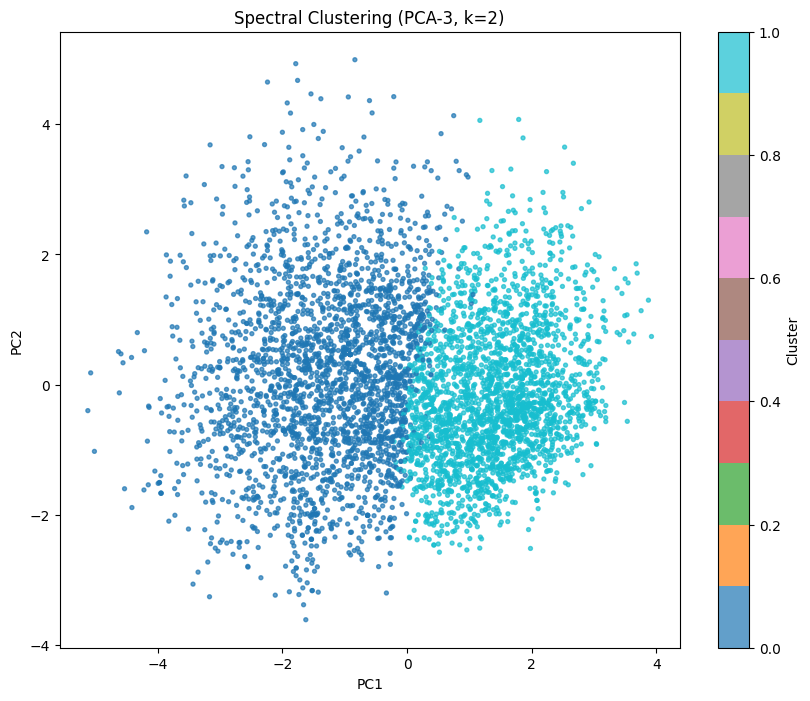

In [8]:
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt

X_spectral = spectral_pca["pca_3"]

spectral_k2 = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=42
)

labels_spectral_k2 = spectral_k2.fit_predict(X_spectral)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_spectral[:, 0],
    X_spectral[:, 1],
    c=labels_spectral_k2,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.title("Spectral Clustering (PCA-3, k=2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster")
plt.show()

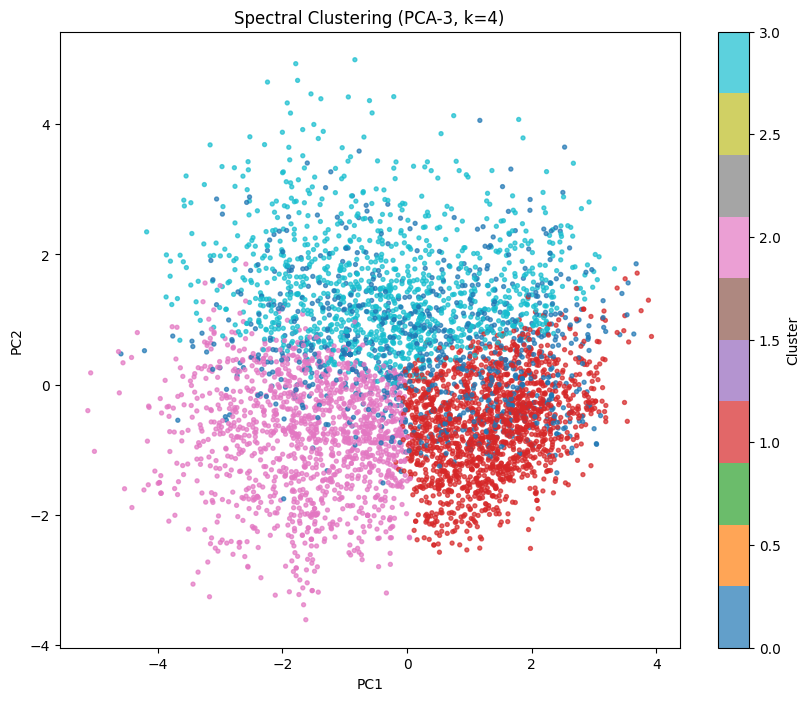

In [9]:
spectral_k4 = SpectralClustering(
    n_clusters=4,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=42
)

labels_spectral_k4 = spectral_k4.fit_predict(X_spectral)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_spectral[:, 0],
    X_spectral[:, 1],
    c=labels_spectral_k4,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.title("Spectral Clustering (PCA-3, k=4)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster")
plt.show()

### Vizuelna analiza klastera

Vizuelizacija najbolje konfiguracije pokazuje da Spectral Clustering sa 2 klastera deli prostor na dve velike i gotovo podjednako zastupljene grupe. Granica izmedju klastera formira se uglavnom duz prve glavne komponente, pri cemu postoji odredjeno preklapanje u centralnom delu prostora.

Kako bi se ispitalo da li podaci sadrze finiju strukturu, analizirana je i konfiguracija sa 4 klastera. U ovom slucaju algoritam uspeva da izdvoji cetiri relativno kompaktne grupe koje zauzimaju razlicite regione PCA prostora.

Medjutim, iako konfiguracija sa 4 klastera omogucava detaljniju segmentaciju podataka, ostvaruje nizi Silhouette Score od modela sa 2 klastera. To ukazuje da su granice izmedju grupa manje izrazenе i da se klasteri u vecoj meri preklapaju.

Na osnovu vizuelne analize moze se zakljuciti da Spectral Clustering uspesno identifikuje osnovnu strukturu podataka. Model sa 2 klastera daje jasnije razdvajanje i bolju internu metriku, dok model sa 4 klastera otkriva dodatnu strukturu podataka po cenu slabije razdvojenosti klastera.

In [10]:
print("Spectral k=2")
print(pd.Series(labels_spectral_k2).value_counts(normalize=True) * 100)

print("\nSpectral k=4")
print(pd.Series(labels_spectral_k4).value_counts(normalize=True) * 100)

Spectral k=2
0    51.4
1    48.6
Name: proportion, dtype: float64

Spectral k=4
1    32.26
2    27.30
3    22.04
0    18.40
Name: proportion, dtype: float64


In [ ]:
pd.Series(labels_spectral_k2).to_csv(
    "../../models/spectral_labels.csv",
    index=False
)

In [ ]:
np.save("../../models/spectral_sample_idx.npy", spectral_idx)

In [ ]:
np.save(
    "../../models/X_spectral_pca3.npy",
    X_spectral
)